<a href="https://colab.research.google.com/github/pr31988/Python-Projects-colab/blob/main/Market_Competitor_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>
<h1><font size=5><b>Project 2 - Market Competitor Intelligence System</font></h1>

# **Problem Scenario**

**Allied FinServ**, a financial investment company, often find themselves operating in a high-stakes investment landscape where speed and accuracy are paramount.

A key task is making intelligent, data-driven investment decisions by analysing competition through competitor analysis (market intelligence) report.

Traditional market analytics and research is resource-intensive, requiring days or weeks of manual effort to gather, validate, and synthesize data, with heavy reliance on a fragmented, manual supply chain of information that slows down every stage of the process—from discovery to final report.

Analysts must visit dozens of disconnected sources manually—competitor websites, SEC filings (10-Ks/10-Qs), news portals, and paid industry databases (e.g., Bloomberg, Gartner), requiring a resource-intensive as well as significant manual effort to gather, validate, and synthesize information - a process that spans anywhere from days to weeks.

Another hurdle is that key financial data is often locked in static PDFs, while strategic updates are buried in earnings call transcripts or press releases - extracting this data requires reading and manual copy-pasting, which is slow and tedious


# **Business Objective**

**Allied FinServ** is looking to create an agentic workflow system to automated the market intelligence report generation from a reactive, labor-intensive bottleneck into a proactive, automated strategic asset.

By automating the process, the company is looking to transform its existing manual workflow, which is reactive, labor-intensive bottleneck into a proactive, automated strategic asset.

By decomposing the task into sequential steps, each handled by specialized agents, the system ensures that the analysis process is efficient, accurate, and scalable.

The system will utilize an Agent based Retrieval-Augmented Generation (RAG) architecture to reduce the time-to-insight from weeks to minutes, enabling investment teams to capitalize on market movements faster than the competition.

The workflow will start with users providing the company name as input (“Tesla”), and the workflow will perform an automated analysis that will:
- identify its top competitors,
- retrieve the latest web data,
- compare key business metrics and strategic attributes, and
- generate a structured, actionable competitor analysis report.

# **Proposed Workflow**

The Automated Market Competitor Intelligence workflow broadly consists of the following steps:
- Accepts a company name as input - `Tesla`
- The `Question Generator` generate a list of relevant queries pertaining to the industry and the company
- A `Research Agent` retrieves answers to the queries generated by the `Question Generator` agent usings the tools at its disposal:
    - `web_search_tool` to formulate answers regarding the latest and industry-specific data from online sources
    - `rag_tool` to extract relevant information from internal/ propriterary documents
- The questions and the answers are then shared with the `Report Drafter` agent, which parses the output results, and structures the output using the output format provided to create a structured and actionable competitor analysis report.


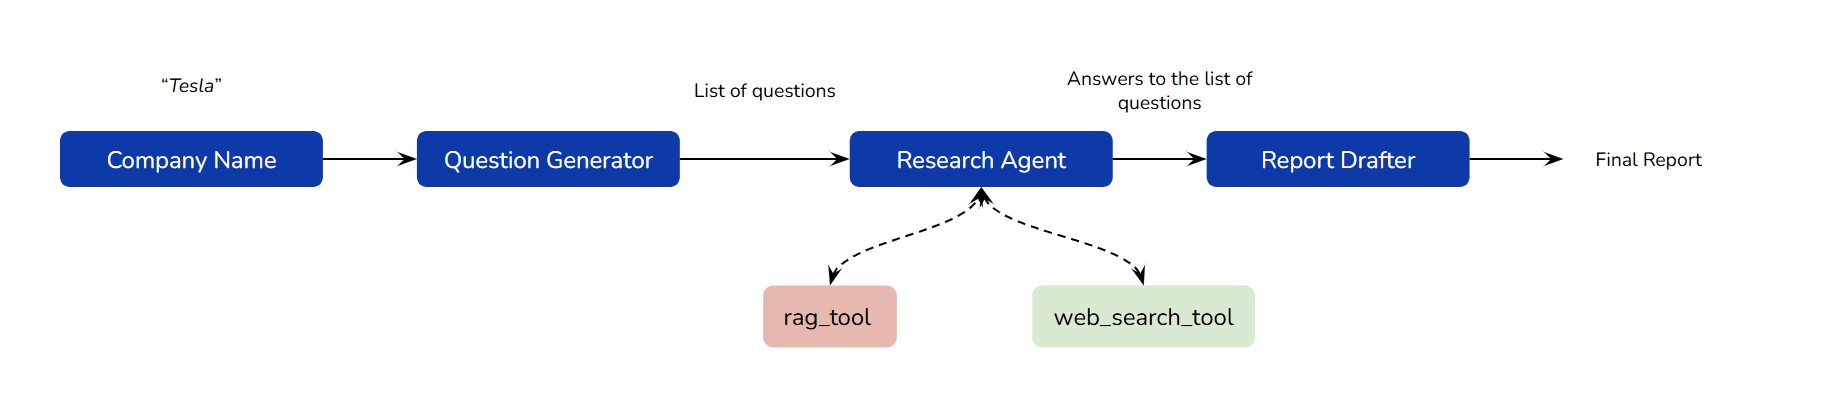

# **Project Overview**

The project is structured into five core phases, designed to transition from environment configuration to the delivery of an automated market intelligence report:

**1. Foundational Environment Setup**

This initial phase focuses on provisioning the necessary resources and libraries to power the agent.

- **Library Installation**: Core frameworks are installed, including openai (for model access), langchain and langgraph (for workflow orchestration), pypdf (for document parsing), and beautifulsoup4 (for web data extraction).

- **Infrastructure & Credentials**: The system initializes API imports and configures secure access to Azure OpenAI and the Tavily Search API.

- **Model Calibration**: Both the Language Model (LLM) and Embedding Model are instantiated with the requried configuration, ensuring the outputs are deterministic, logical, and consistent.

**2. Tool Configuration & Intent Routing**

In this section, the agent is equipped with "senses" to gather information from various sources.

- **Hybrid Search Tools**: Two primary tools are initialized: the `tavily_web_search_tool` for real-time internet data and the `rag_tool` for querying proprietary internal knowledge bases.

- **LLM Binding**: These tools are bound to the LLM, transforming it into a "routing engine" that can dynamically decide which source to query based on the user's specific information needs.

**3. Agent Architecture: State and Functional Nodes**

This phase defines the "brain" and "memory" of the system.

- **Workflow State:** A specialized data structure is created to act as a "shared digital clipboard," maintaining context (company name, research questions, and findings) as the project moves through the pipeline.

**Modular Nodes:**

- **Question Generator**: Acts as a strategist to identify the industry sector and draft high-value research questions.

- **Research Agent**: An execution node that runs an agentic loop to answer questions by toggling between internal documents and live web searches.

- **Report Drafter**: A synthesis node that transforms raw data into a structured Markdown report, complete with SWOT analyses and strategic recommendations.

**4. Workflow Orchestration & Pipeline Execution**

Here, individual nodes are connected to form a seamless, automated assembly line.

- **Sequential Graph**: The nodes are organized into a linear progression: START → Question Generation → Researching → Drafting → END.

- **Compilation & Invocation**: The workflow is compiled into a runnable application that manages state transitions and error handling. When triggered with the comapny name ("Tesla"), the system autonomously moves through each stage—from planning to synthesis—without manual intervention.

**5. Strategic Summary & Extensibility**

The final section evaluates the project's performance and future potential.
- **Key Takeaways**: Outlines key takeaways from the project.
- **Business Impact**: Summarizes how this automation enhances decision-making and operational efficiency.
- **Future Roadmap**: Proposes improvements such as persistent databases, "Human-in-the-Loop" validation steps, and expanded document format support.


# **Data Overview**

The project leverages a dual-stream data approach to ensure a comprehensive and grounded analysis.

It integrates real-time web intelligence via the **Tavily Search API** to capture the latest market trends and competitor news, alongside authoritative corporate records sourced from Tesla's official [quarterly disclosures](https://ir.tesla.com/#quarterly-disclosure).

By ingesting primary documents such as SEC filings and shareholder decks, the system cross-references "ground-truth" financial data with live external context for queries, enabling the agent to produce reports that are both historically accurate and contextually up-to-date.

NOTE: *Since the report needs to be relevant and up-to-date with the latest information, we'll limit the scope of the project within the year 2025.*

# **Installing and Importing the Necessary Libraries**

* The `openai` library is the official OpenAI SDK for interacting with models like gpt-4o-mini, used in the notebook.

* `langchain` framework can be used for building applications using LLMs with tool-use, memory, chains, and agents.

* `langchain-openai` provides the integration layer between LangChain and the OpenAI SDK.

* `langchain-community` consists of community-contributed integrations (tools, loaders, retrievers, etc.) for LangChain.

* `langgraph` will be used for graph-based workflow engine for building LLM agents with stateful and cyclic logic.

* `pypdf` library will be used for reading, merging, and extracting text from PDF files.

* `beautifulsoup4` will be used for parsing web data

In [ ]:
# Installing the Libraries
!pip install -q \
    openai==1.66.3 \
    langchain==0.3.21 \
    langchain-core==0.3.48 \
    langchain-text-splitters==0.3.7 \
    langchain-openai==0.3.9 \
    langchain-community==0.3.19 \
    langgraph==0.3.21 \
    langgraph-checkpoint==2.0.21 \
    pydantic==2.10.6 \
    pypdf==5.4.0 \
    beautifulsoup4==4.13.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.0/186.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/3

## Importing the Libraries

In [ ]:
# Importing Libraries
import os # For interacting with the operating system

import base64 # For encoding binary data (e.g., image bytes) into base64

import json # For reading/writing JSON data

import uuid # For generating unique identifiers

import math # For mathematical functions and constants

import numexpr # For evaluating numerical expressions efficiently

from datetime import datetime # For date time operations

from IPython.display import Markdown, Image, display

# Type definitions for structured inputs/outputs
from typing import Annotated, TypedDict, List, Optional, Dict, Tuple # For defining structured types
from typing_extensions import Annotated # Annotated typing for tool input metadata

from pydantic import BaseModel, Field, ConfigDict # Pydantic Model Configuration for the Agent State

from openai import OpenAI, AzureOpenAI # LM class from OpenAI library

# LangChain imports
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage # Added AIMessage for agent responses

from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings, ChatOpenAI, OpenAIEmbeddings # LangChain-compatible OpenAI chat & embedding model

from langchain_core.vectorstores import InMemoryVectorStore # In-memory vector store for semantic search or RAG workflows

from langchain_core.messages import SystemMessage, HumanMessage # Core message types for LangChain workflows

from langchain.tools import tool, StructuredTool # For defining tools usable by LLMs

from langchain_core.documents import Document # LangChain's schema class for representing text + metadata for retrieval tasks

from langchain_core.prompts import ChatPromptTemplate # LangChain's Chat Prompt Template

from langchain.text_splitter import RecursiveCharacterTextSplitter # Text splitter for chunking documents

from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader # Document Loader to deal with PDF files and Webpages

from langchain_community.tools import TavilySearchResults # LangChain Tool for searching online via Tavily Search API

# LangGraph components for building agentic workflows as graphs
from langgraph.graph import StateGraph, START, END # Langgraph's building blocks

from langgraph.graph.message import add_messages # Utility to merge or propagate messages between nodes

from langgraph.prebuilt import ToolNode, tools_condition, create_react_agent  # Prebuilt agent nodes and patternss

# **1. Environment Setup (4 Marks)**

## 1.1 Model Selection

In this section, provide details of the models used in the project, its function and the reason for selecting the model.

## 1.2 Model and Tool Instantiation (2 Mark)

In [ ]:
# Load OpenAI API Key from colab secrets
from google.colab import userdata
# azure_api_key = userdata.get('azure_api_key')

azure_api_key = userdata.get('openai_api_key') # Azure OpenAI API Key
azure_endpoint = userdata.get('openai_endpoint') # Azure Endpoint URL
azure_api_version = userdata.get('openai_api_version') # Azure API Version

embedding_model_endpoint = userdata.get('embedding_model_endpoint')

# Model Names
model_name = "gpt-5-mini"
embedding_model = "text-embedding-3-small"

The following code block initializes Tavily API Key for performing web search.

You can signup/ login to [Tavily](https://www.tavily.com/) by creating a free account.

Tavily provides **Free Plan** which provides 1,000 free API Credits every month.

In [ ]:
# Tavily Search API for Web Search
tavily_api_key = userdata.get('tavily_api_key')
os.environ["TAVILY_API_KEY"] = tavily_api_key

## 1.3 LLM and Embedding Model Initialization (1 Marks)

In [ ]:
# Instantiate the LLM and Embedding Model using Azure OpenAI Models
llm = AzureChatOpenAI(
    # LLM Configuration Details
    model= model_name,
    api_version = azure_api_version,
    api_key = azure_api_key,
    azure_endpoint = azure_endpoint
)

# Instantiate the Embedding Model
embedding_model = AzureOpenAIEmbeddings(
    # Embedding model Configuration Details
     azure_deployment= embedding_model, # Your Azure Deployment Name
    openai_api_version= azure_api_version,
    azure_endpoint= embedding_model_endpoint, # embedding model end point
    api_key= azure_api_key # embedding model API key is same as that of openai api key in azure
)

In [ ]:
## Test LLM & Embedding model
#llm.invoke('hi')
embedding_model.embed_query('hi')

[-0.003753662109375,
 -0.0191802978515625,
 0.01221466064453125,
 0.03277587890625,
 0.0161895751953125,
 -0.037261962890625,
 -0.028228759765625,
 0.06500244140625,
 0.0009646415710449219,
 -0.057525634765625,
 0.0014333724975585938,
 -0.03265380859375,
 -0.0307464599609375,
 0.004779815673828125,
 0.032928466796875,
 0.0192413330078125,
 -0.04193115234375,
 -0.0029048919677734375,
 0.024749755859375,
 0.046630859375,
 0.03778076171875,
 0.034149169921875,
 -0.00243377685546875,
 0.0362548828125,
 0.0163421630859375,
 0.0018634796142578125,
 0.0021209716796875,
 -0.00887298583984375,
 0.032073974609375,
 -0.026336669921875,
 0.0013456344604492188,
 -0.037811279296875,
 0.02581787109375,
 -0.037017822265625,
 -0.01654052734375,
 -0.0126495361328125,
 -0.025604248046875,
 0.033050537109375,
 0.0155181884765625,
 -0.03778076171875,
 0.0249786376953125,
 -0.004978179931640625,
 0.046478271484375,
 0.015869140625,
 -0.019805908203125,
 0.015655517578125,
 -0.0269775390625,
 0.0164642333984

## 1.4 Get the Current Date (1 Mark)

We'll initialize a variable `current_date` that keeps track of the current date for the report generation process. This variable will used to provide a reference date for restricting the search results to the relevant timeframe and in the final report generation process.

In [ ]:
# Get the current date
from datetime import date
current_date = date.today()
current_date

datetime.date(2026, 9, 12)

# **2. Setting up the Tools (10 Marks)**

In this section, we'll set up the Tools required to solve the business objective, namely Tavily search tool that searches for information online and the RAG tool that retrievs information from propietary documents.

## 2.1 Tavily Search Tool (3 Marks)

The following code defines the `tavily_web_search_tool` that acts as a real-time web search interface for the AI agent. It allows the system to bypass its training data cutoff and retrieve up-to-date information from the live internet.

The tool function performs targeted retrieval by searching the web based on the `query` for market data, competitor news, financial metrics (like revenue), and product reviews For every input query, the tool returns the results based on the top most relevant search results defined by the `num_results` argument and the source URL, ensuring the data can be cited and verified. There is robust error handling to report search failures gracefully without crashing the system.


In [ ]:
@tool
def tavily_web_search_tool(query: str, num_results = 3) -> str:
    """
    Performs a real-time web search using the Tavily API to retrieve up-to-date market data.

    This tool is designed to bypass the LLM's knowledge cutoff by fetching current information
    regarding competitors, financial metrics, recent news, and product reviews.

    Args:
        query (str): The search string to send to the search engine.
        num_results (int, optional): The maximum number of search results to return.
                                     Defaults to 3 to manage token usage.

    Returns:
        str: A formatted string containing the content and source URLs of the search results,
             or an error message if the search fails.
    """
    # Note: Ensure TAVILY_API_KEY is in your environment variables or passed explicitly
    try:
        # Initialize the Tavily Search Tool with a limit on results
        # Limiting results helps prevent overflowing the LLM's context window
        tavily_tool = TavilySearchResults(max_results=3)

        # Execute the search query with the .invoke method to handle the API call to Tavily
        results = tavily_tool.invoke({"query": query})

        # Validate if any results were returned
        if not results:
            return [f"no search result returned for the query:"]

        if isinstance(results, str):
          try:
            search_data = json.loads(results)
          except json.JSONDecodeError:
            return ["Error: Tavily returned text that could not be parsed as valid JSON objects."]
        else:
          search_data = results

        # Initialize an empty list to hold the processed strings
        formatted_results = []

        # Iterate through the raw results to format them for the LLM
        for i, result in enumerate(results, 1):

            # Extract the text snippet (content) safely, providing a default if missing
            content = result.get("content", "No content found")

            # Extract the source URL for citation purposes
            url = result.get("url", "No URL found")

            # Append the results
            # Format the output to clearly separate content from its source url
            # This structure helps the LLM distinguish between facts and citations
            formatted_entry = f"URL: {url}\nContent: {content}"
            formatted_results.append(formatted_entry)

        # Join all formatted results into a single string separated by double newlines
        return formatted_results

    except Exception as e:
        # Gracefully handle exceptions (e.g., API errors, connection issues)
        # Returning the error as a string allows the Agent to see what went wrong
        return ("Tavily API call error:", e)

In [ ]:
# # Testing the 'tavily_web_search_tool' using a sample query
search_result = tavily_web_search_tool("What is the weather in France today?")
print(search_result)

/tmp/ipykernel_1735/1595344303.py:2: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  search_result = tavily_web_search_tool("What is the weather in France today?")


['URL: https://www.youtube.com/shorts/ZTGtYQaclFc\nContent: A rather cool morning in several regions, before a nice rise in temperatures throughout the day. Morning: 8 to 20°C ☀️ Afternoon: 18 to 29°C 🔥', 'URL: https://weather.metoffice.gov.uk/world/france\nContent: ## Find a forecast\n\nNearest forecast to your detected location\n\nSuggested places \n\nUse my current location\n\nRecent places \n\n# Top locations\n\n Paris Sunny intervals 25°C\n Marseilles Sunny day 27°C\n Lyon Sunny day 27°C\n Toulouse Int. Sunny day 27°C\n Nice Sunny day 28°C\n Nantes Sunny day 25°C\n Strasbourg Sunny intervals 25°C\n Montpellier Aeroport Med. Sunny day 28°C\n Bordeaux Sunny day 27°C\n Lille Sunny intervals 22°C\n\nView all locations in France\n\nweather map\n\nForecast\n\nForecast for 1pm (UTC+1) Saturday\n\nUpdated 11:14 (UTC+1) on Sat 12 Sep 2026\n\nLoading map...\n\n## Help us improve our website\n\nTake our short survey\n\n Home\n All countries\n France', 'URL: https://www.euronews.com/2026/09/1

## 2.2 RAG Tool (6 Marks)

In this section, we'll initialize the RAG tool to retrieve information from the source documents/ folder provided as input.

The functionality has been split into two sub-sections:
- **Vector store initialization** that serves as the database for ingesting the documents, chunking and embedding the texts. The code can be used to ingest PDF documents using LangChain's [PyPDFLoader](https://docs.langchain.com/oss/python/integrations/document_loaders/pypdfloader) or optionally, process content from web URLs using the LangChain's [WebBaseLoader](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
- **RAG Tool** which serves as the internal knowledge retrieval interface for the AI agent by  retrieving the information from the vector store for a given query using similarity search.  

### 2.2.1 Initialize the Vector Store (3 Marks)

The following code defines the `initialize_rag_vector_store` function, which serves as the data ingestion engine for the RAG system. Its primary purpose is to aggregate and index unstructured data from multiple sources into a searchable knowledge base.

The function performs three key operations:
- Data Loading: It ingests content from a specified local folder containing PDF documents and/or a list of external web URLs.
- Text Chunking: It processes the raw text using a recursive character splitter to break documents into manageable segments (chunks) suitable for analysis.
- Vector Storage: It embeds these chunks using the provided embedding model and stores them in an InMemoryVectorStore, enabling the system to perform semantic similarity searches for internal context.


In [ ]:
def initialize_rag_vector_store(
    embedding_model,
    pdf_folder_path: Optional[str] = None,
    urls: Optional[List[str]] = None
) -> InMemoryVectorStore:
    """
    Initializes and populates an InMemoryVectorStore with chunked documents from PDFs and URLs.

    This function acts as the data ingestion pipeline for the RAG system:
    1. Extract: Loads raw text from local PDF files and remote web URLs.
    2. Transform Splits text into managed chunks (1000 chars) with overlap to preserve context across boundaries.
    3. Load Embeds these chunks using the provided model and indexes them in an in-memory vector database.

    Args:
        embedding_model: The initialized LangChain embedding model (e.g., AzureOpenAIEmbeddings)
                         used to convert text chunks into vector representations.
        pdf_folder_path (Optional[str]): Local directory path containing PDF reports (e.g., annual reports, 10-Ks).
                                          Defaults to None.
        urls (Optional[List[str]]): List of web addresses to scrape for supplementary context.
                                    Defaults to None.

    Returns:
        InMemoryVectorStore: The initialized vector store containing the embedded document chunks,
                             ready for semantic similarity search.
    """
    # Initialize an empty list to hold all processed document chunks
    all_documents = []

    # Initialize the Recursive Text Splitter with chunk size and chunk_overlap
    text_splitter = RecursiveCharacterTextSplitter(
                chunk_size=1000,
                chunk_overlap=200,
                length_function=len,
                is_separator_regex=False,
                separators=["\n\n", "\n", " ", ""] # Priority: Paragraphs -> Lines -> Words -> Chars
    )

    # --- Step 1: Process PDF Files (Local Data) ---
    if pdf_folder_path:
        print(f"Attempting to load PDFs from folder: {pdf_folder_path}")

        # Validate folder existence
        if not os.path.exists(pdf_folder_path):
            print(f"Warning: PDF folder not found at {pdf_folder_path}. Skipping PDF loading.")
        else:
            # Filter for .pdf files (case insensitive)
            pdf_files = list(pdf_folder_path.glob("*.pdf"))

            if not pdf_files:
                print(f"No PDF files found in folder: {pdf_folder_path}.")

            # Iterate through each PDF file found
            for pdf_file in pdf_files:
                full_pdf_path = os.path.join(pdf_folder_path, pdf_file)
                try:
                    print(f"  Loading PDF: {pdf_file}")

                    # Use PyPDFLoader to extract text page-by-page
                    pdf_loader = PyPDFLoader(full_pdf_path)
                    # Load the pages
                    pdf_docs = pdf_loader.load()

                    if pdf_docs:
                        print(f"    Loaded {len(pdf_docs)} pages from {pdf_file}. Chunking...")

                        # Split the loaded pages into smaller text chunks using the .split_documents method
                        chunked_pdf_docs = text_splitter.split_documents(pdf_docs)

                        # Extend the list by adding the documents
                        all_documents.extend(chunked_pdf_docs)

                        print(f"    Added {len(chunked_pdf_docs)} chunks from {pdf_file}.")
                    else:
                        print(f"    Warning: No content extracted from PDF: {pdf_file}.")

                except Exception as e:
                    # Catch errors for individual files so one bad PDF doesn't stop the whole process
                    print(f"    Error loading or processing PDF {pdf_file}: {e}")

    # --- Step 2: Process URLs if present ---
    if urls:
        print(f"Attempting to load content from URLs: {urls}")
        try:
            # Use WebBaseLoader to scrape text from the provided URLs
            web_loader = WebBaseLoader(urls)
            web_docs = web_loader.load()

            if web_docs:
                print(f"Loaded {len(web_docs)} documents from URLs. Chunking...")

                # Split the scraped web content into chunks using the .split_documents method
                chunked_web_docs = text_splitter.split_documents(web_docs)

                # Extend the lisit with the chunked web documents
                all_documents.extend(chunked_web_docs)

                print(f"Added {len(chunked_web_docs)} chunks from URLs.")
            else:
                print(f"Warning: No content loaded from the provided URLs: {urls}.")

        except Exception as e:
            print(f"Error loading or processing URLs {urls}: {e}")

    # --- Step 3: Create Vector Store ---
    # Check if we successfully gathered any data
    if not all_documents:
        print("No documents were loaded from any source. Returning an empty vector store.")
        # Return an empty store to prevent downstream errors
        return InMemoryVectorStore(embedding=embedding_model)

    print(f"\nTotal chunks to add to vector store: {len(all_documents)}")

    # Initialize the InMemoryVectorStore
    # This acts as a temporary database holding the vectors during the script's runtime
    vector_store = InMemoryVectorStore(embedding_model)

    # Add the documents to the store
    # This step triggers the embedding_model to convert text chunks into vector embeddings using the .add_documents method
    document_ids = vector_store.add_documents(all_documents)

    print(f"Successfully added {len(document_ids)} document chunks to the vector store.")

    return vector_store

Initialize the vector store

In [ ]:
# Command to unzip the data form the .zip folder
!unzip data.zip

Archive:  data.zip
   creating: data/
  inflating: data/Industry Report on Electric Cars.pdf  
  inflating: data/tsla-20250331.pdf  
  inflating: data/tsla-20250630.pdf  
  inflating: data/tsla-20250930.pdf  
  inflating: data/TSLA-Q1-2025-Update.pdf  
  inflating: data/TSLA-Q2-2025-Update.pdf  
  inflating: data/TSLA-Q3-2025-Update.pdf  


In [ ]:
# --- Data Ingestion & Knowledge Base Initialization ---
from pathlib import Path
print("--- Initializing Internal Knowledge Base ---")

# Call the helper function to process documents and build the vector index
# The resulting 'global_rag_vector_store' acts as the searchable database for the RAG tool.
global_rag_vector_store = initialize_rag_vector_store(
    embedding_model,
    pdf_folder_path = Path('/content/data/')
    #urls = ''
)

print(f"--- Knowledge Base Ready ---")

--- Initializing Internal Knowledge Base ---
Attempting to load PDFs from folder: /content/data
  Loading PDF: /content/data/tsla-20250630.pdf
    Loaded 38 pages from /content/data/tsla-20250630.pdf. Chunking...
    Added 157 chunks from /content/data/tsla-20250630.pdf.
  Loading PDF: /content/data/Industry Report on Electric Cars.pdf
    Loaded 7 pages from /content/data/Industry Report on Electric Cars.pdf. Chunking...
    Added 15 chunks from /content/data/Industry Report on Electric Cars.pdf.
  Loading PDF: /content/data/tsla-20250331.pdf
    Loaded 36 pages from /content/data/tsla-20250331.pdf. Chunking...
    Added 146 chunks from /content/data/tsla-20250331.pdf.
  Loading PDF: /content/data/TSLA-Q1-2025-Update.pdf
    Loaded 32 pages from /content/data/TSLA-Q1-2025-Update.pdf. Chunking...
    Added 67 chunks from /content/data/TSLA-Q1-2025-Update.pdf.
  Loading PDF: /content/data/TSLA-Q2-2025-Update.pdf
    Loaded 30 pages from /content/data/TSLA-Q2-2025-Update.pdf. Chunking...

### 2.2.2 RAG Tool (3 Marks)

The following code defines the `rag_tool`, which serves as the internal knowledge retrieval interface for the AI agent. It allows the system to access and reference proprietary data—such as PDF reports, company policies, and internal context—that is not available on the public web.

The function executes a semantic similarity search against the pre-loaded in-memory vector store. It retrieves the top `k` relevant document chunks matching the input query and combines them into a single text response, providing the agent with the necessary context to answer specific, data-driven questions based on the uploaded documents.


In [ ]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the internal knowledge base (PDF documents).
    Use this tool FIRST when asked about:
    - Internal company strategy or specific report details.
    - Historical data contained in uploaded SEC filings or earnings reports.
    - Any information that is likely proprietary and not just general web news.

    Args:
        query (str): The search string to match against the document embeddings.

    Returns:
        str: A consolidated string of the top 3 most relevant document chunks.
    """
    try:
        # Perform a Semantic Similarity Search
        # It converts the user's query into a vector and finds the closest matching vectors in the database similarity search
        # It then queries the 'global_rag_vector_store' and retrieves top k (3) most relevant chunks to provide sufficient context
        # without exceeding the LLM's token limit.
        results = global_rag_vector_store.similarity_search(query, k=3)

        # Check if the search yielded any results
        if not results:
            return ('vector store similarity search is empty')

        # Process the results
        # The search returns a list of 'Document' objects - Extract the raw text (page_content) from each and join them into a single string.
        return results

    # Graceful Error Handling
    except Exception as e:
        # If the vector store isn't initialized or the search fails, return an error message
        # This allows the Agent to realize the tool failed and potentially try a different strategy (like web search) instead of crashing the program.
        return ('the vector store is not initialized or search has failed:', e)

In [ ]:
# # Testing the 'rag_tool' using a sample query
query = "What are the key trends in the electric car industry?"
search_result = rag_tool.invoke({"query": query})
print(search_result)

[Document(id='8338e196-8e9d-4fee-8df8-a82a3c988ab0', metadata={'producer': 'Skia/PDF m145 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Electric Car - Industry Report', 'source': '/content/data/Industry Report on Electric Cars.pdf', 'total_pages': 7, 'page': 0, 'page_label': '1'}, page_content='1.  Executive  Summary  \nAs  the  global  automotive  industry  closes  out  2025,  the  electric  vehicle  (EV)  landscape  \nhas\n \nundergone\n \na\n \nseismic\n \nshift.\n \nThe\n \nera\n \nof\n \nsingle-brand\n \ndominance\n \nby\n \nTesla\n \nhas\n \neffectively\n \nended,\n \nreplaced\n \nby\n \na\n \nfierce\n \nduopoly\n \nwith\n \nBYD\n,\n \nwhich\n \nhas\n \ncemented\n \nits\n \nstatus\n \nas\n \nthe\n \nworld’s\n \nvolume\n \nleader.\n \n2025  has  been  defined  by  the  "Chinese  Surge"  and  the  "Legacy  Struggle."  While  \nChinese\n \nOEMs\n \nlike\n \nBYD\n \nand\n \nGeely\n \nhave\n \nseen\n \naggressive\n \nglobal\n \nexpansion\n \nand\n \ndouble-d

## 2.3 Create Tools list and integrate with LLM (1 Mark)


Now that the tools have been defined, the tools must be coupled with the LLM. This allows the model to see the tool definitions (names, descriptions, arguments) so it can decide *which* tool to call and *how* to call it.

This is solved by creating a **tool registry**, that acts as a bridge between the custom python functions and the AI agent, providing awareness of the tools and the actions it can perform.

The following code initializes a `tools_list` which bundles the Web Search and RAG ools into a single collection, which is later bound to the LLM so it knows which tools are available for use.

In [ ]:
# --- Tool Registration & Mapping ---

# Create a master list of Tools which can be passed to the LLM via the .bind_tools() method
tools_list = [tavily_web_search_tool,
              rag_tool]

The following code integrates the tools with the LLM using the `.bind_tools` method to automatically convert the Python tool definitions (and their type hints) into the specific JSON schema required for OpenAI's function-calling API.

The tool_choice argument empowers the model to dynamically decide whether to call a tool or generate plain text based on the context, rather than forcing a specific action.

In [ ]:
# --- Tool Binding ---

# the .bind_tools method provides the LLM instance with a list of tools.
# This method performs two key actions:
# 1. Schema Conversion: It converts the Python function definitions (docstrings, args, type hints) into the specific JSON schema required by the model for function calling.
# 2. Capability Awareness: It tells the model "Here are the tools you have permission to use."
llm_with_tools = llm.bind_tools(
    tools_list
)

By providing the `tavily_web_search_tool` and `rag_tool` to the LLM, we have transformed it into a routing engine.
For any given query, the model now evaluates the context and chooses the best path:
- External Data: Uses tavily_web_search_tool for current events or stock data.
- Internal Data: Uses rag_tool for proprietary documents.
- General Knowledge: Uses no tool and relies on its training data for general questions (e.g., "What is Tesla?").

When the LLM decides to use a tool, it does not run the code itself. Instead, it pauses generation and returns a structured Tool Call object containing the intent to run a function.

For example, if asked "Latest stock information for Tesla," the llm_with_tools response includes a `.tool_calls` attribute as shown below:

```
[{
  'name': 'tavily_web_search_tool',
  'args': {'query': 'Tesla latest stock information', 'num_results': 3},
  'id': 'call_zlkkVFd7kKnfW9a0dAFX5a2W',
  'type': 'tool_call'
}]
```

Crucially, the LLM outputs text/JSON, not executable code. It knows the name of the tool ("tavily..."), but it does not have access to the actual Python object.

The tools_map dictionary bridges this gap - it serves as a registry that maps the string names provided by the LLM to the actual executable functions in your code.
```
Input: String from LLM ("rag_tool")
Lookup: tools_map["rag_tool"]
Result: Actual Python function (<function rag_tool at 0x...>)
```
This allows the system to dynamically translate the LLM's "thoughts" into immediate software "actions."

The code below creates a `tools_map`, which serves as a registry linking tool names to their actual Python implementations.

Since the LLM outputs text (e.g., the string "tavily_web_search_tool"), it cannot directly trigger code execution.

This dictionary bridges that gap by mapping those string identifiers to the executable function objects. This enables the system to dynamically look up and run the correct function based on the LLM's decision.


In [ ]:
# Create the Execution Map (Tool Registry)
# The LLM returns tool calls as strings (e.g., "rag_tool"), but Python needs objects to run code.
# This dictionary maps the tool's name (string) -> the actual function object (callable).
tools_map = {
   "rag_tool": rag_tool,
   "tavily_web_search_tool": tavily_web_search_tool
}

The following code tests the tool calling functionality of the LLM against test queries.

In [ ]:
# Testing LLM tool call usage
query_1 = "What is Tesla?" # Will result in LLM invocation with no tool call
query_2 = "Latest stock information for Tesla" # Will result in tavily_web_search_tool invocation
query_3 = "Tesla Q3 2025 performance based on provided documents" # will result in rag_tool invocation

query_list = [query_1, query_2, query_3]

for query in query_list:
    # 1. Ask the LLM
    msg = llm_with_tools.invoke(query)

    # 2. Check if it wants to use a tool
    if msg.tool_calls:
        # Loop through all tool calls (LLMs can sometimes call multiple tools at once)
        for tool_call in msg.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]

            print(f"LLM wants to call: {tool_name} with args: {tool_args}")

            # 3. DYNAMICALLY EXECUTE THE TOOL
            # Check if the requested tool actually exists in our map
            if tool_name in tools_map:
                # Select the tool function from the dictionary
                selected_tool = tools_map[tool_name]

                # Run the tool
                tool_output = selected_tool.invoke(tool_args)

                print(f"Tool Output ({tool_name}): {tool_output}")
            else:
                print(f"Error: LLM requested unknown tool '{tool_name}'")
        print('-'* 50)

    else:
        print("LLM did not call a tool.")
        print("Response:", msg.content)
        print('='* 50)

LLM did not call a tool.
Response: Do you mean Tesla the company or tesla the unit of magnetic flux density? Brief answers for both:

- Tesla (company): An American electric-vehicle and clean-energy company founded in 2003 (co‑founders include Martin Eberhard and Marc Tarpenning; Elon Musk joined early and is the best-known CEO). Headquartered in Austin, Texas, Tesla designs and manufactures electric cars (Model S, 3, X, Y, Cybertruck prototype, Semi), battery products (Powerwall, Powerpack, Megapack), and solar products. Its mission is to accelerate the world’s transition to sustainable energy. It’s publicly traded under the ticker TSLA.

- tesla (unit, symbol T): The SI unit of magnetic flux density (magnetic field strength). One tesla equals one weber per square meter; in base SI units it’s kg·s⁻²·A⁻¹. It’s a large unit (1 tesla = 10,000 gauss).

Which one would you like to know more about?
LLM wants to call: tavily_web_search_tool with args: {'query': 'Tesla stock price TSLA latest

# **3. Setting up the Agent State and Nodes (13 Marks)**

## Agent State

The following codes define the State definitions (data structure) that organize information within the AI workflow using Pydantic. This enforces strict typing, ensuring the data passed between the AI and the code is consistent and error-free.

We define two states:

- `QuestionSuggestion` - This is a structured output shema for the `Question-Generator` agent. This acts as a strict template for the AI's brainstorming phase. Instead of replying with unstructured text, the AI is forced to provide a precise JSON object containing the industry sector, a validity check, and a specific list of questions, making the output easy for the subsequent agents to parse.

- `CompetitiveAnalysisState` - This forms the core workflow memory for the agent workflow. This state serves as the shared memory (or "blackboard") for the entire LangGraph workflow. The state can be used to input variables from the user (`company_name`, `max_num_of_questions`) to the `Question-Generator` agent. As the system moves through its workflow steps—such as researching, and report-drafting—this state object is passed along to track inputs (like `question_list`), accumulate research findings (`research_context`), and store the final report (`report`). An optional state variable `error_message` is also include for agent to keep track of the error messages in any part of the workflow.


In [ ]:
# --- LLM Structured Output Schema ---

class QuestionSuggestion(BaseModel):
    """
    Defines the strict schema for the LLM's output during the Question Generation phase.

    By passing this class to the LLM (via .with_structured_output), we force the model
    to return a valid JSON object instead of unstructured chat text. This ensures
    our code can reliably parse the results without regex or error-prone string manipulation.
    """
    sector: str = Field(
        #default=None,
        description="The industry sector (e.g., 'EV', 'Technology') identified for the company."
    )

    is_valid_company: bool = Field(
        validate_default=True,
        description="Boolean flag indicating if the LLM recognizes the company entity."
    )

    questions: List[str] = Field(
        default_factory=list,
        description="A list of specific, strategic questions generated for the analysis."
    )

# --- LangGraph Workflow State ---

class CompetitiveAnalysisState(BaseModel):
    """
    Defines the State (Shared Memory) for the LangGraph workflow.

    As the workflow moves from Node to Node (Generator -> Researcher -> Drafter),
    this object is passed along and updated. It serves as the single source of truth
    for all data accumulated during the lifecycle of the analysis.
    """

    # --- Input Fields (Provided by User) ---
    company_name: str  # The target company to analyze
    max_num_of_questions: int = 5  # Limit on scope

    # --- Intermediate Fields (Populated by Agents) ---
    sector: Optional[str] = None  # Populated by Question Generator Node
    question_list: List[str] = [] # Populated by Question Generator Node

    # Stores the raw findings from RAG and Web Search - the string grows as the Research Node processes questions.
    research_context: str = ""

    # --- Output Fields (Final Deliverable) ---
    #report: Optional[str] = None  # The final Markdown report populated by Drafter Node
    report: str = ""

    # --- Error Handling ---
    error_message: Optional[str] = None # Captures exceptions to prevent the workflow from crashing

Now that the States have been defined, we define the individual nodes for the workflow.

As previously mentioned, we'll utilize the sequential workflow consisting of the following agent nodes:

- **Question Generator Node**: For a input company (Tesla), agent generates a list of questions.

- **Research Node**: This nodes takes as input the list of question, retrieves context from the web or from the provided documents using web_search_tool or rag_tool respectively and retrieves research_contexts along with the sources.

- **Report Generator Node**: This node will utilize the research_context to create a structured output following the format provided in the agent instructions.

## 3.1 Question Generator Node (4 Marks)

The following code defines the `question_generator_node`, which serves as the strategic planning phase of the analysis workflow. Its primary purpose is to scope the research project before data collection begins.

The function performs three key actions:
- Contextual Prompting: It instructs the AI to adopt the persona of a Market Research Expert and injects the current date. This ensures the generated questions are relevant to the present economic climate (e.g., asking about 2025 financial trends rather than outdated 2021 data).
- Sector Identification: It automatically identifies the industry sector of the target company to tailor the analysis.
- Structured Brainstorming: It uses structured output generation to force the AI to produce a specific list of high-value questions focused on market position, competitor analysis, and investor interests, rather than generic chatter. This list is then saved to the workflow state to guide the subsequent research steps.

In [ ]:
def question_generator_node(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Node for Strategic Planning & Question Generation.

    This function serves as the entry point for the analysis workflow.
    It instructs the LLM to act as a Market Research Expert to:
    1. Identify the industry sector of the target company.
    2. Generate a specific list of strategic questions to guide the research.

    Args:
        state (CompetitiveAnalysisState): The current state of the workflow containing
                                          the 'company_name' and 'max_num_of_questions'.

    Returns:
        state (CompetitiveAnalysisState): The updated state, now populated with the identified 'sector'
                                  and the list of 'question_list'.
    """

    print(f"--- [1] Generating Questions for {state.company_name} (Date: {current_date}) ---")

    # 1. Define the System Instruction
    # Ensure that the instruction is able to capture the high-level business metrics for the current timeframe rather than generic trivia
    system_instruction = """You are a Market Research Expert to:
                         1. Identify the industry sector of the target company.
                         2. Generate a specific list of strategic questions to capture the high-level current business metrics and to guide the research."""

    # 2. Create the Prompt Template
    # We provide the inputs (i.e. company name) directly into the string and the maximum number of questions to be generated
    prompt = ChatPromptTemplate.from_messages([
        (
          "system", "{system_instruction}"
        ),
      # User input for company name and maximum number of questions
        (
          "human",
          "Generate questions about {company_name}, "
          "not more than {max_num_of_questions} questions."
        )
      ])

    # 3. Chain the prompt to the LLM configured for Structured Output .with_structured_output(QuestionSuggestion)
    # It forces the LLM to return a strict JSON object matching the QuestionSuggestion Pydantic schema (sector, is_valid_company, questions)
    chain = prompt | llm.with_structured_output(QuestionSuggestion)

    try:
        # 4. Invoke the Chain
        # We pass an empty dict {} because we already formatted the prompt strings above.
        result = chain.invoke({
             "system_instruction": system_instruction,
             "company_name": state.company_name,
             "max_num_of_questions": state.max_num_of_questions
        })

        # 5. Update the State by extracting the structured data and saving it to the workflow state
        # so the next node (Research Node) can access these specific questions.
        state.sector = result.sector
        state.question_list = result.questions

        # Logging for visibility
        # Print the sector and Questions
        print(f"   > Identified Sector: {state.sector}")
        print(f"   > Generated {len(state.question_list)} strategic questions.")

    # 6. Error Handling
    except Exception as e:
        # If the LLM fails to generate valid JSON or the API times out, we capture the error to prevent the entire workflow from crashing.
        print("There is error", e)
        state.error_message = e

    # Return State
    return state

This completes the Question Generator part of the workflow.

The list of questions from this node is now routed to the Research Node, which takes the list of questions, retrieves context from online sources or from documents using the provided tools.

## 3.2 Research Node (5 Marks)

The following code defines the `research_node`, which functions as the intelligence gathering engine of the workflow. It executes the actual research by iterating through the list of questions generated in the previous step and finding answers using the most appropriate data source.

The function operates through an "Agentic Loop" that performs three critical tasks:
- Hybrid Information Retrieval: For every question, the AI dynamically decides whether to use the **RAG Tool** (for analyzing internal documents like SEC filings and earnings reports) or the **Web Search Tool** (for real-time market data and competitor stats), ensuring the best source is used for each specific query.
- Temporal Context Injection: It injects the current date and year into every prompt. This prevents the AI from retrieving outdated information and forces it to search for the most recent financial data (e.g., "Q4 2025 revenue").
- Result Aggregation: It executes the chosen tools, captures the raw data, and synthesizes the findings for all questions into a single, comprehensive research context string that will be used to write the final report.


In [ ]:
def research_node(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Node 2: The Agentic Research Loop.
    This function acts as the execution engine. It iterates through the questions generated
    in the previous step and answers them by dynamically selecting the best source of information.
    The Logic Flow:
    1. Bind Tools: Connects the LLM to the RAG and Web Search tools.
    2. Iterate: Loops through every question in the 'question_list'.
    3. Decide: Asks the LLM "Which tool should I use to answer this?"
    4. Execute: Manually runs the tool requested by the LLM and captures the output.
    5. Accumulate: Aggregates all findings into a single context string.
    Args:
        state (CompetitiveAnalysisState): Current workflow state containing the 'question_list'.

    Returns:
        state (CompetitiveAnalysisState): Updated state with 'research_context' populated.
    """
    print(f"--- [2] Researching (Using RAG & Web Tools) | Date: {current_date} ---")

    # Safety Check: If no questions exist, skip research.
    if not state.question_list:
        print("   > No questions found. Skipping research.")
        return state

    # 1. Bind Tools to the LLM
    llm_with_tools = llm.bind_tools(tools_list)

    # Initialize a list to hold the raw answers found for each question
    accumulated_context = []

    # 2. Process Each Question
    for i, question in enumerate(state.question_list):
        print(f"   > Researching Q{i+1}: {question}")

        # Construct the Decision Prompt to explicitly guide the LLM on WHEN to use WHICH tool.
        # - Use rag_tool for official documents (SEC filings, earnings reports, shareholder letters).
        # - Use tavily_web_search_tool for real-time data (market news, competitor stats, general web info).
        # Search Constraint: You must include the current year in all web search queries to ensure freshness.
        research_prompt = """- Use rag_tool for official documents (SEC filings, earnings reports, shareholder letters).
                             - Use tavily_web_search_tool for real-time data (market news, competitor stats, general web info)
                              You must include the current year in all web search queries to ensure freshness."""

        # 3. Invoke the LLM (The "Brain")
        # The LLM returns a message that might contain text content OR a 'tool_call' request.
        msg = llm_with_tools.invoke([("system", research_prompt),
                                     ("human", question)])

        q_result = ""

        # 4. Check for Tool Calls (The "Hands")
        if msg.tool_calls:
            # The LLM decided it needs external data. It returns a JSON object
            # specifying the function name and arguments.

            for tool_call in msg.tool_calls:
                tool_name = tool_call["name"]
                tool_args = tool_call["args"]

                print(f"     [Tool Call] {tool_name} with args: {tool_args}")

                # Retrieve the actual Python function from our map
                selected_tool = tools_map[tool_name]

                # EXECUTE the tool manually
                # The LLM cannot run code; we must run it and capture the string output.
                try:
                    tool_output = selected_tool.invoke(tool_args)
                except Exception as e:
                    tool_output = (f"Error: LLM requested unknown tool '{tool_name}'")

                # Format the resulting tool call (tool name and tool output) to append to our context
                if isinstance(tool_output, list):
                   tool_output += "\n\n".join(
                   doc.page_content if hasattr(doc, "page_content") else str(doc)
                   for doc in tool_output
                   )
                elif not isinstance(tool_output, str):
                   tool_output = str(tool_output)
                q_result += (f"tool name: {tool_name}\nOUTPUT: {tool_output}\n" + "-"*30)
        else:
            # Fallback: If the LLM didn't call a tool (rare, given the instructions),
            # we accept its internal training knowledge as the answer.
            q_result = ("LLM did not call a tool. Respose is:",msg.content)

        # 5. Accumulate Findings
        # We save the Question + The Tool's Answer into the context list.
        accumulated_context.append(f"QUESTION: {question}\nFINDINGS: {q_result}\n" + "-"*30)

    # 6. Update State - Join all findings to the research_context state
    state.research_context = "\n".join(accumulated_context)

    # Return the updated State
    return state

This completes the Research Node.

The list of questions and the retrieved contexts via the Research Node arw now shared with the Report Drafter Node, which synthesises the raw information and transforms it into a structured document.  

## 3.3 Report Drafter Node (4 Marks)

The following code defines the `report_drafter_node`, which serves as the synthesis and writing phase of the workflow. It acts as the final analyst, taking the raw information gathered during the research phase and transforming it into a polished, professional document.

The function performs three critical operations:
- Context Integration: It ingests the disjointed raw data collected from both the internal documents (RAG) and external web searches, treating them as a single comprehensive knowledge base.
- Structural Enforcement: It imposes a strict, professional format on the output, ensuring the final report includes specific sections: Executive Summary, Market Position, SWOT Analysis, Competitor Analysis, and Strategic Recommendations.
- Report Generation: It uses the Large Language Model to write the narrative, connecting the data points into a cohesive story that addresses the specific company and sector identified at the start of the workflow.


In [ ]:
def report_drafter_node(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Node 3: Final Report Synthesis.

    This function acts as the "Writer" agent. It takes the disjointed notes and raw data
    collected during the Research phase and compiles them into a structured, professional
    document suitable for stakeholders.

    Key Actions:
    1. Context Integration: Ingests the 'research_context' (RAG + Web findings).
    2. Prompt Engineering: Enforces a strict structure (SWOT, Recommendations).
    3. Content Generation: Uses the LLM to write the final Markdown report.

    Args:
        state (CompetitiveAnalysisState): Current workflow state containing 'research_context',
                                          'company_name', and 'sector'.

    Returns:
        state (CompetitiveAnalysisState): Updated state with the final 'report' string populated.
    """

    print(f"--- [3] Drafting Report for {state.company_name} | Date: {current_date} ---")

    # 1. Define the Report Prompt Template
    # We provide strict structural instructions to ensure consistency.
    # Note: We specifically ask the model to base the report on the provided {context}
    # to minimize hallucinations.
    prompt_template = """You are a Business Metric Analysis Agent for a market competitor intelligence system.

Your task is to analyze the provided business content and generate a structured business metric analysis report.

IMPORTANT SOURCE RESTRICTION:
- Use ONLY the information explicitly available in the provided content.
- Do not use external knowledge, web searches, assumptions, or prior knowledge.
- Do not invent, estimate, or infer numerical values that are not present in the content.
- If a metric or required piece of information is not available, use null or "Not available in provided content".
- Clearly distinguish between facts explicitly stated in the content and analytical observations derived directly from those facts.

ANALYSIS GUIDELINES:
1. Identify the company and industry sector when supported by the content.
2. Extract relevant business metrics such as revenue, growth, market share, customers, users, pricing, funding, profitability, valuation, or other metrics mentioned in the content.
3. Preserve the original units and currency of reported metrics.
4. Do not calculate new metrics unless the required values are explicitly provided and the calculation is straightforward.
5. When making a comparison, compare only metrics available in the provided content.
6. Do not rank competitors unless the provided content supports the ranking.
7. Do not treat claims or forecasts as actual results.
8. Identify trends only when they are supported by multiple pieces of information in the content.
9. If information is ambiguous, state the ambiguity rather than guessing.
10. Keep the analysis concise, factual, and evidence-based.

STRICT OUTPUT STRUCTURE:

Return the report using exactly the following structure:

{
  "company": {
    "name": "",
    "sector": "",
  },

  "business_metrics": [
    {
      "metric": "",
      "value": "",
      "unit": "",
      "period": "",
      "source_context": ""
    }
  ],

  "performance_analysis": {
    "growth": "",
    "financial_performance": "",
    "market_position": "",
    "customer_metrics": "",
    "other_observations": ""
  },

  "competitive_insights": [
    {
      "insight": "",
      "supporting_metric": "",
      "comparison": ""
    }
  ],

  "key_strengths": [],

  "key_risks": [],

  "information_gaps": [],

  "overall_summary": ""
}

STRICT FORMAT RULES:
- Return only the requested structured output.
- Do not add sections that are not defined above.
- Do not change field names.
- Do not omit fields. Use null, an empty list, or "Not available in provided content" when information is unavailable.
- `business_metrics` must always be an array.
- `competitive_insights` must always be an array.
- `key_strengths`, `key_risks`, and `information_gaps` must always be arrays.
- Do not use Markdown outside the structured output.
- Keep metric values faithful to the provided content.
- Do not fabricate sources or citations.

PROVIDED CONTENT:

{content}

USER QUERY:

{query}"""

    # 2. Create the Chain
    prompt = ChatPromptTemplate.from_messages([
        ("system", "{prompt_template}"),
        # User input for company name and research_context
        ("human", """
        Generate a competitive analysis report for {company_name},
        which operates in the {sector} sector.

        Use the following research findings as the source material:

        {research_context}

        Do not return null.
        Generate the report strictly based on the provided research findings.
        Do not invent facts, metrics, or comparisons that are not supported
        by the research context.
        """)
    ])

    # Chain the Prompt to the LLM for generating the report
    chain = prompt | llm.with_structured_output(CompetitiveAnalysisState)

    try:
        # 3. Invoke the LLM
        # We pass all necessary variables from the state variable to be passed to the the prompt_template.
        # Enter values for company_name, sector, context and date from the State
        response = chain.invoke({
            "prompt_template": prompt_template,
            "company_name": state.company_name,
            "sector": state.sector,
            "research_context": state.research_context,
        })

        # 4. Store the Result
        state.report = response.report
        print("   > Report drafted successfully.")
        print("RESPONSE:")
        print(response)

        print("\nRESPONSE TYPE:")
        print(type(response))

        print("\nRESPONSE DICT:")
        print(response.model_dump())

    except Exception as e:
        # 5. Perform Error Handling
        print("report generation failure", e)
        state.error_message = e
        # Save report error in the report state
        state.report = "Report generation failed due to an internal error."

    # Return the State
    return {
        "report": response.report
    }
    print("Generated report:", state)


We've now defined all the Nodes required for the Workflow. So far, we've created the:

- Question Generator Node
- Research Node
- Report Drafter Node

The following section creates a sequential workflow pattern that links these nodes in a linear execution path.

This ensures that the output of one step (like the generated questions) flows directly as input into the next (the research process), culminating in the final report.


# **4. Create and Execute the Workflow (7 Marks)**

## 4.1 Create the Workflow (3 Marks)

The following code segment is responsible for orchestrating the entire operation and organizes the individual tasks (nodes) into a coherent, executable pipeline.

In this code, we initialize the workflow with the CompetitiveAnalysisState - which acts as a shared digital clipboard that holds all project info such as the questions, the research findings, and the final draft. Every worker on the assembly line will be handed this clipboard, add their notes to it, and pass it to the next person.


Once the workflow is initialized, Node Registration is performed. This section registers the three agent nodes or 'specialized workers' - question_generator, research-agent, report_drafter - are add as distinct nodes within the graph. This identifies who does the work.


Once the **workers** have been defined, we now define the assembly line that determines overall rules on sequantial processing:
START → Generator → Researcher → Drafter → END
The rule translates as follows:
```
START: The workflow begins.
Hand-off 1: The START goes to the Question Generator.
Hand-off 2: Once the questions are written, the CompetitiveAnalysisState state (clipboard) is handed to the Researcher.
Hand-off 3: Once the research is done, the CompetitiveAnalysisState state (clipboard) is handed to the report-drafter.
END: Once the report is written, the workflow completes and the project is finished.
```
The above workflow ensures that research cannot begin until questions are generated, and the report cannot be written until research is complete.

Once the workflow has been defined, we compile the workflow using the `.compile()` method. The `.compile()` method freezes the workflow structure into an executable Application. This transforms the abstract definitions into a runnable agent that manages the state (memory) as it moves through the defined steps.


In [ ]:
# 1. Initialize the Graph
# We create a StateGraph using our specific schema defined earlier.
# This acts as the "Manager" that holds the shared memory and passes it between steps.
# Every node in this graph will receive this State as input and return an updated State.
workflow = StateGraph(CompetitiveAnalysisState)

# 2. Add Nodes (a.k.a the "Workers")
# We register the Python functions defined earlier as official nodes in the graph.
workflow.add_node("question-generator", question_generator_node)
workflow.add_node("researcher", research_node)
workflow.add_node("writer", report_drafter_node)

# 3. Define Edges (a.k.a the "Assembly Line") to determine the flow of execution.
# The following will define a sequential flow

workflow.add_edge(START, "question-generator")
workflow.add_edge("question-generator", "researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)

# 4. Compile the Application
agent_workflow = workflow.compile()

The following code displays the Langgraph workflow

In [ ]:
# Visualize the Workflow
try:
    display(
    Image(
          agent_workflow.get_graph().draw_mermaid_png()
    )
  )
except Exception as e:
    print(f"Could not display graph: {e}")

## 4.2 Execute the Workflow (2 Marks)

The following code segment serves as the launch trigger for the entire competitor analysis system. It is the point where the abstract workflow defined previously is instantiated with concrete user data and executed to produce a result.

The code performs two decisive actions:
- State Initialization (input_data): It creates the initial state object, acting as the input payload for the system. Here, the user defines the specific target of the analysis and sets the scope of research by defining the maximum number of questions which controls the depth and breadth of the study.
- Synchronous Execution (.invoke): It calls the .invoke() method to start the workflow. This passes the input data into the graph, triggers the sequential chain of agents (Question Generation → Research → Drafting), and captures the final state, which will contain the completed report and all intermediate research data.

Initialize the input data to research the company name - "Tesla"

In [ ]:
# Enter the company name and the maximum number of questions as input data to the agent workflow via the defined state
input_data = CompetitiveAnalysisState(
    company_name = "Tesla",
    max_num_of_questions= 5
)

input_data

CompetitiveAnalysisState(company_name='Tesla', max_num_of_questions=5, sector=None, question_list=[], research_context='', report='', error_message=None)

In [ ]:
# Invoke the agent workflow with the input data
final_state = agent_workflow.invoke(input_data)

--- [1] Generating Questions for Tesla (Date: 2026-09-12) ---
   > Identified Sector: Electric Vehicles & Clean Energy (Automotive / Energy Tech)
   > Generated 5 strategic questions.
--- [2] Researching (Using RAG & Web Tools) | Date: 2026-09-12 ---
   > Researching Q1: What are Tesla's most recent revenue and margin metrics by segment (Automotive, Energy Generation & Storage, Services & Other), including vehicle average selling price (ASP) and trends over the last four quarters?
     [Tool Call] rag_tool with args: {'query': 'Tesla revenue by segment Automotive Energy Generation & Storage Services & Other vehicle average selling price ASP last four quarters revenue and gross margin quarterly 2026 2025 2024 Tesla earnings report segment results'}
   > Researching Q2: What are Tesla's current global production capacity and utilization rates by factory and model, actual vehicle deliveries by model, and the expected ramp schedules/backlog for new factories or major model updates?
     [T

In [ ]:
# Display the final_state
#final_state

{'company_name': 'Tesla',
 'max_num_of_questions': 5,
 'sector': 'Electric Vehicles & Clean Energy',
 'question_list': ['What are Tesla’s most recent production and delivery volumes by model and region, and how are those trends quarter-over-quarter and year-over-year?',
  'What is the current revenue and gross margin breakdown across Automotive, Energy Generation & Storage, and Services & Other — including the contribution from regulatory credits and software (FSD) subscriptions?',
  'What is Tesla’s current liquidity and free cash flow position, and what are the planned capital allocations (capex, Gigafactory buildouts, battery investments, and debt/service obligations) over the next 12–24 months?',
  'What are Tesla’s unit economics: average selling price (ASP) per vehicle, cost of goods sold per vehicle (notably battery costs), and the expected trajectory for margin improvements from scale and technology (battery/cell innovations)?',
  'What are the primary operational constraints a

In [ ]:
# Display the final_state
#type(final_state)
print("report key exists:", "report" in final_state)
print("report value:", repr(final_state["report"]))
print("report type:", type(final_state["report"]))

report key exists: True
report value: '{\n  "company": {\n    "name": "Tesla",\n    "sector": "Electric Vehicles & Clean Energy (Automotive / Energy Tech)"\n  },\n\n  "business_metrics": [\n    {\n      "metric": "Automotive sales revenue (three months ended Sep 30, 2025)",\n      "value": "20,359",\n      "unit": "$ millions",\n      "period": "Three months ended September 30, 2025",\n      "source_context": "From Consolidated Statements of Operations (Three Months Ended September 30, 2025): Automotive sales $20,359 (in millions)"\n    },\n    {\n      "metric": "Total automotive revenues (three months ended Sep 30, 2025)",\n      "value": "21,205",\n      "unit": "$ millions",\n      "period": "Three months ended September 30, 2025",\n      "source_context": "Total automotive revenues $21,205 (includes sales, regulatory credits and leasing)"\n    },\n    {\n      "metric": "Energy generation and storage revenue (three months ended Sep 30, 2025)",\n      "value": "3,415",\n      "unit

## 4.3 Display the Final Report (1 Marks)

The following code segment serves as the presentation layer of the application. Its purpose is to deliver the final results of the analysis to the user in a readable format or provide feedback if the process failed.

The code performs a critical conditional check:
- Verification & Rendering: It checks if a report was successfully generated in the final state. If found, it uses the Markdown display function to render the text with rich formatting (headers, bullet points, bold text) directly in the notebook, making it easy for the user to read and consume.
- Error Feedback: If no report exists (e.g., due to an API failure or data issue), it gracefully handles the failure by retrieving and printing the specific error message stored in the state, helping the user understand what went wrong during execution.


In [ ]:
# Display the Report in human-readable format
if final_state["report"]:
    display(final_state['report'])
else:
    # Display the Error from state
    print("Error:", final_state["error_message"])

'{\n  "company": {\n    "name": "Tesla",\n    "sector": "Electric Vehicles & Clean Energy (Automotive / Energy Tech)"\n  },\n\n  "business_metrics": [\n    {\n      "metric": "Automotive sales revenue (three months ended Sep 30, 2025)",\n      "value": "20,359",\n      "unit": "$ millions",\n      "period": "Three months ended September 30, 2025",\n      "source_context": "From Consolidated Statements of Operations (Three Months Ended September 30, 2025): Automotive sales $20,359 (in millions)"\n    },\n    {\n      "metric": "Total automotive revenues (three months ended Sep 30, 2025)",\n      "value": "21,205",\n      "unit": "$ millions",\n      "period": "Three months ended September 30, 2025",\n      "source_context": "Total automotive revenues $21,205 (includes sales, regulatory credits and leasing)"\n    },\n    {\n      "metric": "Energy generation and storage revenue (three months ended Sep 30, 2025)",\n      "value": "3,415",\n      "unit": "$ millions",\n      "period": "Thr

## 4.4 Save the Report (1 Mark)

The following code results of the workflow to a report in the format mentioned:
`<company>_market_report_<current_date>`

In [ ]:
# Save the report to a text file
company = final_state["company_name"]
filename = f'{company}_market_report_{current_date}.txt'
with open(filename, "w", encoding='utf-8') as file:
    file.write(final_state["report"]) # Write the report to the text file
    print("File saved")

File saved


In [ ]:
## Display the .txt file
!cat "{company}_market_report_{current_date}.txt"

{
  "company": {
    "name": "Tesla",
    "sector": "Electric Vehicles & Clean Energy (Automotive / Energy Tech)"
  },

  "business_metrics": [
    {
      "metric": "Automotive sales revenue (three months ended Sep 30, 2025)",
      "value": "20,359",
      "unit": "$ millions",
      "period": "Three months ended September 30, 2025",
      "source_context": "From Consolidated Statements of Operations (Three Months Ended September 30, 2025): Automotive sales $20,359 (in millions)"
    },
    {
      "metric": "Total automotive revenues (three months ended Sep 30, 2025)",
      "value": "21,205",
      "unit": "$ millions",
      "period": "Three months ended September 30, 2025",
      "source_context": "Total automotive revenues $21,205 (includes sales, regulatory credits and leasing)"
    },
    {
      "metric": "Energy generation and storage revenue (three months ended Sep 30, 2025)",
      "value": "3,415",
      "unit": "$ millions",
      "period": "Three months ended September 

# **5. Concluding Remarks (6 marks)**

This part of the project helps you demonstrate your ability to think beyond code and explain how your solution creates real value in a business setting. You'll describe the Key Takeaways of building the project, improvements to the workflow where and how your project could be used, who would benefit, and why it matters.

## **5.1 Key Takeaways  (2 marks)**

1. how to build stateful, validated, source grouding agent.
2. process of creating in-memory RAG
3. Buildling a sequential node-workflow using clipboard to maintain state, where each node passes an input to the next

## **5.2 Expected Business Impact (2 marks)**

Produce a human readable raw-text (mark-down) report to reduce the analysis time. Increase the information accuracy. The real-time thorough analysis report helps to make a confident and high-quality decision.

## **5.3 Improvements to the Workflow (2 Marks)**


1. Add output validation after each Node. For example handle conditions: if No questions genearated, If Research_context is empty or If reponse.report is empty return appropriate error message
2. Add a conditional validation to route the workflow. This can also help in re-try logic instead of immedieate failure
3. Update research node to fetch the source details of generated information, to make it trustworthy.
4. Add logging, monitoring, authentication to make it production ready.